<a href="https://colab.research.google.com/github/ARMAAN15092007/25BAI0198_EDA/blob/main/EXP%20-%206%20%7C%2018.08.2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/content/WineQT.csv")

In [6]:
print(df.head(3))
print(df.tail(3))

   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   

   alcohol  quality  Id  
0      9.4        5   0  
1      9.8        5   1  
2      9.8        5   2  
      fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
1140            6.2             0.600         0.08             2.0      0.090   
1141            5.9             0.550         0.10             2.2      0.062   
1142            5.9             0.645      

In [9]:
df.dtypes

,0
fixed acidity,float64
volatile acidity,float64
citric acid,float64
residual sugar,float64
chlorides,float64
free sulfur dioxide,float64
total sulfur dioxide,float64
density,float64
pH,float64
sulphates,float64


In [10]:
print(df.describe())

       fixed acidity  volatile acidity  citric acid  residual sugar  \
count    1143.000000       1143.000000  1143.000000     1143.000000   
mean        8.311111          0.531339     0.268364        2.532152   
std         1.747595          0.179633     0.196686        1.355917   
min         4.600000          0.120000     0.000000        0.900000   
25%         7.100000          0.392500     0.090000        1.900000   
50%         7.900000          0.520000     0.250000        2.200000   
75%         9.100000          0.640000     0.420000        2.600000   
max        15.900000          1.580000     1.000000       15.500000   

         chlorides  free sulfur dioxide  total sulfur dioxide      density  \
count  1143.000000          1143.000000           1143.000000  1143.000000   
mean      0.086933            15.615486             45.914698     0.996730   
std       0.047267            10.250486             32.782130     0.001925   
min       0.012000             1.000000         

In [11]:
pd.isna(df).any()

,0
fixed acidity,False
volatile acidity,False
citric acid,False
residual sugar,False
chlorides,False
free sulfur dioxide,False
total sulfur dioxide,False
density,False
pH,False
sulphates,False


In [14]:
df['quality'].astype(str).str.isnumeric().value_counts()

,count
quality,
True,1143


In [17]:
df['quality'].loc[df['quality'].astype(str).str.isnumeric() == False]
quality_clean = df['quality'].loc[df['quality'] != '?']
qmean = quality_clean.astype(float).mean()
df['quality'] = df['quality'].replace('?', qmean).astype(int)
print(df['quality'].head(10))

0    5
1    5
2    5
3    6
4    5
5    5
6    5
7    7
8    7
9    5
Name: quality, dtype: int64


In [18]:
alcohol_clean = df['alcohol'].loc[df['alcohol'] != '?']
almean = alcohol_clean.astype(float).mean()
df['alcohol'] = df['alcohol'].replace('?', almean).astype(float)
print(df['alcohol'].head())

0    9.4
1    9.8
2    9.8
3    9.8
4    9.4
Name: alcohol, dtype: float64


In [30]:
va_clean = df['volatile acidity'].loc[df['volatile acidity'].astype(str).str.replace('.', '', 1).str.isnumeric()]
vamean = va_clean.astype(float).mean()
df['volatile acidity'] = df['volatile acidity'].replace('?', vamean).astype(float)

In [19]:
print(df[df['fixed acidity'] == '?'].count())
fa_count = df['fixed acidity'].loc[df['fixed acidity'] != '?'].count()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64


In [20]:
famean = fa_count.astype(float).mean()
df['fixed acidity'] = df['fixed acidity'].replace('?', famean).astype(float)
print(df['fixed acidity'].head())

0     7.4
1     7.8
2     7.8
3    11.2
4     7.4
Name: fixed acidity, dtype: float64


In [21]:
mean_ph = df["pH"].mean()
median_ph = df["pH"].median()
mode_ph = df["pH"].mode()

In [22]:
print(mean_ph)

3.3110148731408575


In [23]:
print(median_ph)

3.31


In [24]:
print(mode_ph)

0    3.3
Name: pH, dtype: float64


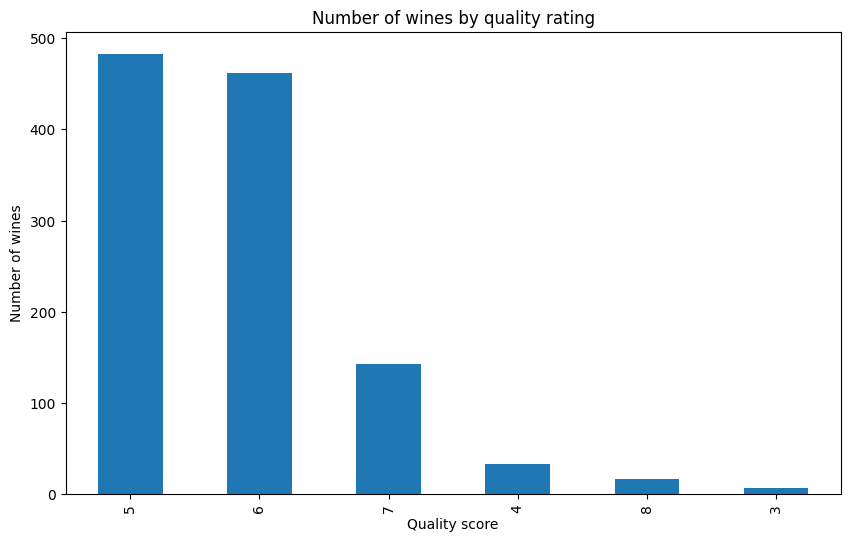

In [25]:
df['quality'].value_counts().nlargest(30).plot(kind='bar', figsize=(10,6))
plt.title("Number of wines by quality rating")
plt.ylabel('Number of wines')
plt.xlabel('Quality score')
plt.show()

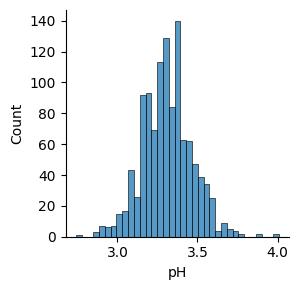

In [26]:
sns.FacetGrid(df).map(sns.histplot, "pH").add_legend()
plt.show()

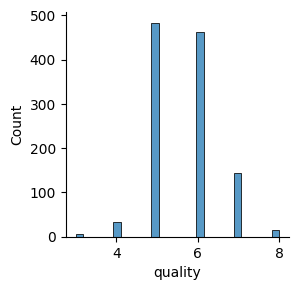

In [27]:
sns.FacetGrid(df).map(sns.histplot, "quality").add_legend()
plt.show()

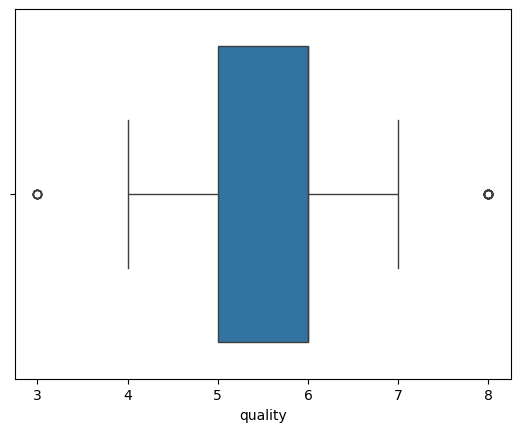

In [28]:
sns.boxplot(x="quality", data=df)
plt.show()

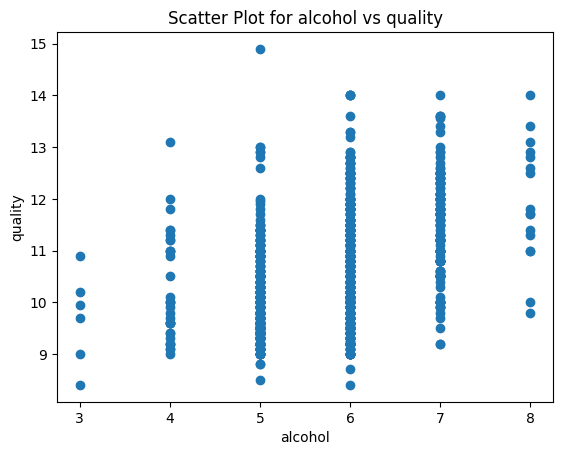

In [29]:
plt.scatter(df["quality"], df["alcohol"])
plt.title("Scatter Plot for alcohol vs quality")
plt.xlabel("alcohol")
plt.ylabel("quality")
plt.show()

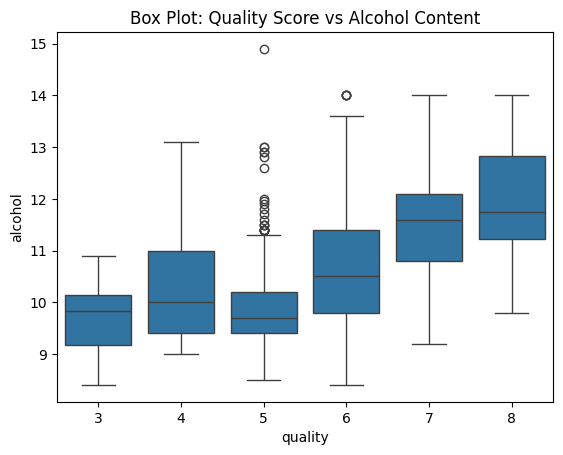

In [31]:
sns.boxplot(x="quality", y="alcohol", data=df)
plt.title("Box Plot: Quality Score vs Alcohol Content")
plt.show()


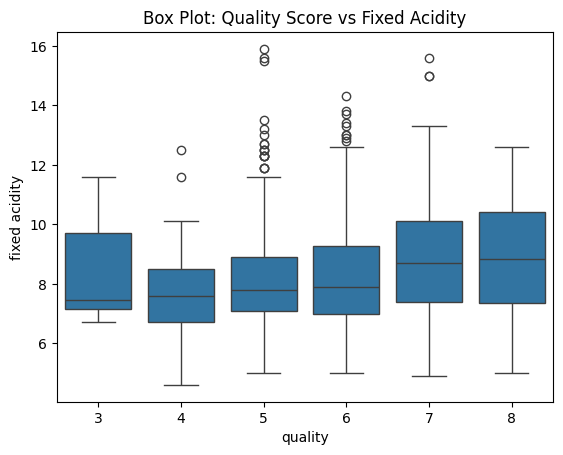

In [32]:
sns.boxplot(x="quality", y="fixed acidity", data=df)
plt.title("Box Plot: Quality Score vs Fixed Acidity")
plt.show()

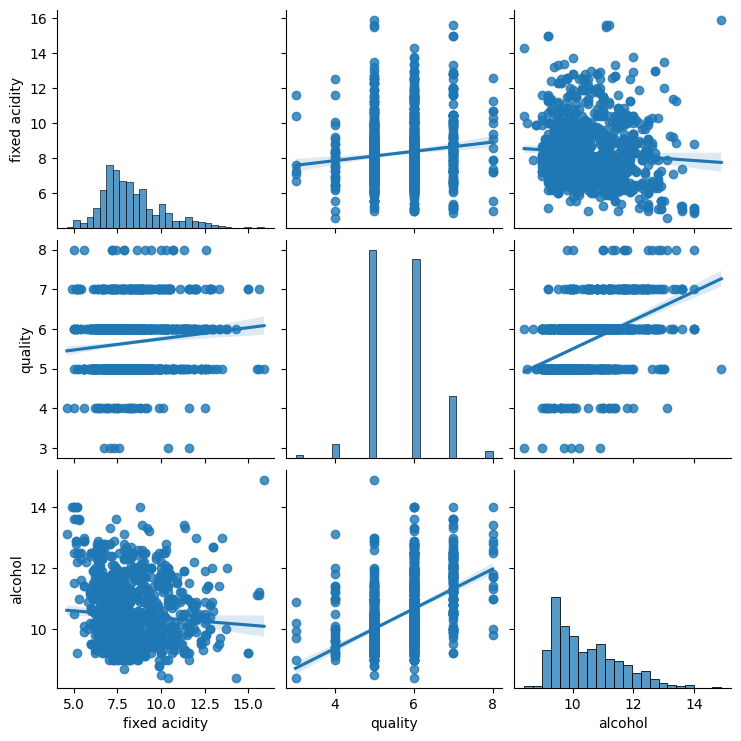

In [33]:
sns.pairplot(df, vars=['fixed acidity', 'quality', 'alcohol'], kind="reg")
plt.show()

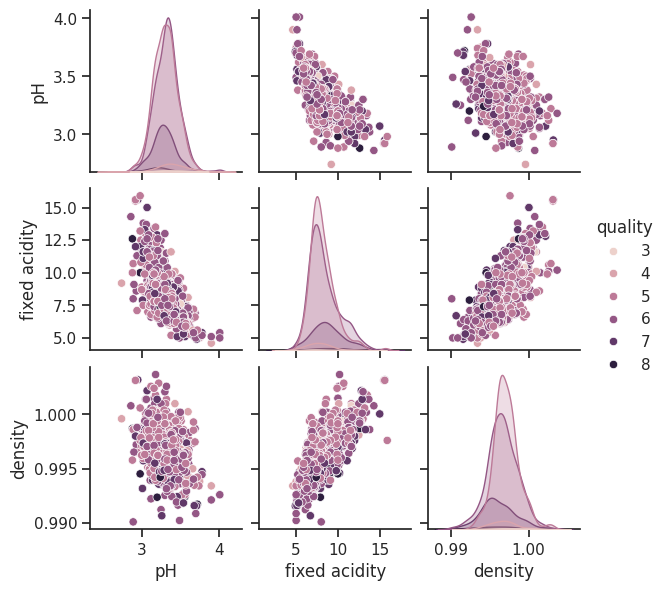

In [34]:
sns.set(style="ticks", color_codes=True)
sns.pairplot(df, height=2, vars=['pH', 'fixed acidity', 'density'], hue="quality")
plt.show()

In [37]:
from scipy import stats


corr_wine = stats.pearsonr(df["quality"], df["alcohol"])
print("p-value:\t", corr_wine[1])
print("cor:\t\t", corr_wine[0])


correlation_matrix = df.corr(method='pearson', numeric_only=True)
print(correlation_matrix)

p-value:	 1.9246528151001656e-68
cor:		 0.4848662118085117
                      fixed acidity  volatile acidity  citric acid  \
fixed acidity              1.000000         -0.250728     0.673157   
volatile acidity          -0.250728          1.000000    -0.544187   
citric acid                0.673157         -0.544187     1.000000   
residual sugar             0.171831         -0.005751     0.175815   
chlorides                  0.107889          0.056336     0.245312   
free sulfur dioxide       -0.164831         -0.001962    -0.057589   
total sulfur dioxide      -0.110628          0.077748     0.036871   
density                    0.681501          0.016512     0.375243   
pH                        -0.685163          0.221492    -0.546339   
sulphates                  0.174592         -0.276079     0.331232   
alcohol                   -0.075055         -0.203909     0.106250   
quality                    0.121970         -0.407394     0.240821   
Id                        -0.27

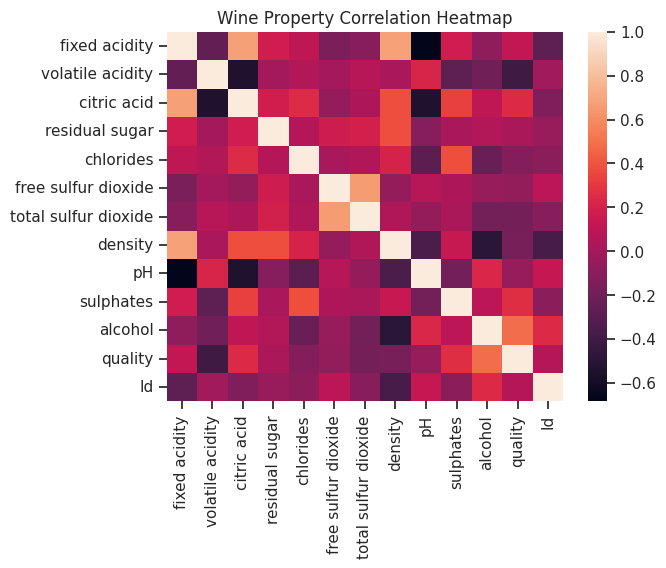

In [38]:
sns.heatmap(correlation_matrix, xticklabels=correlation_matrix.columns, yticklabels=correlation_matrix.columns)
plt.title("Wine Property Correlation Heatmap")
plt.show()